# Segmentation ARCADE : image brute vs latent MedVAE

On fine-tune un UNet sur les images brutes, puis un UNet sur le latent MedVAE (encodeur gelé) pour chaque variante d'encodeur — original, stage 1, stage 2 — et on compare les scores pour mesurer l'effet de la compression.

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp

# Racine du repo (trouvée en remontant jusqu'au .git)
ROOT = str(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / ".git").exists()))
DATA = os.environ.get("ARCADE_ROOT", f"{ROOT}/data/arcade")
sys.path.insert(0, ROOT)
sys.path.insert(0, f"{ROOT}/jepa_adaptation")
from utils.launch import bootstrap, load_config
bootstrap()
from finetune.dataset import ArcadeDataset
from finetune.losses import SegLoss
from finetune.metrics import SegMetrics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 26
IMG_SIZE = 512

def show_rows(images, panels):
    n = images.size(0)
    ncol = 1 + len(panels)
    fig, axes = plt.subplots(n, ncol, figsize=(3 * ncol, 3 * n))
    axes = np.atleast_2d(axes)
    for i in range(n):
        axes[i, 0].imshow(images[i, 0], cmap="gray")
        axes[i, 0].set_title("image")
        for j, (title, masks) in enumerate(panels, start=1):
            axes[i, j].imshow(masks[i], cmap="nipy_spectral", vmin=0, vmax=NUM_CLASSES)
            axes[i, j].set_title(title)
        for j in range(ncol):
            axes[i, j].axis("off")
    plt.tight_layout()
    plt.show()

device

/home/infres/yrothlin-24/.local/share/mamba/envs/IM05/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cuda')

## Dataset de segmentation ARCADE

In [2]:
train_ds = ArcadeDataset(
    f"{DATA}/dataset_phase_1/segmentation_dataset/seg_train/images",
    f"{DATA}/dataset_phase_1/segmentation_dataset/seg_train/annotations/seg_train.json",
    img_size=IMG_SIZE,
    augment=True,
)
val_ds = ArcadeDataset(
    f"{DATA}/dataset_final_phase/test_case_segmentation/images",
    f"{DATA}/dataset_final_phase/test_case_segmentation/annotations/instances_default.json",
    img_size=IMG_SIZE,
    augment=False,
)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=4, pin_memory=True)
len(train_ds), len(val_ds)

/home/infres/yrothlin-24/.local/share/mamba/envs/IM05/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


(1000, 300)

### Quelques exemples annotés

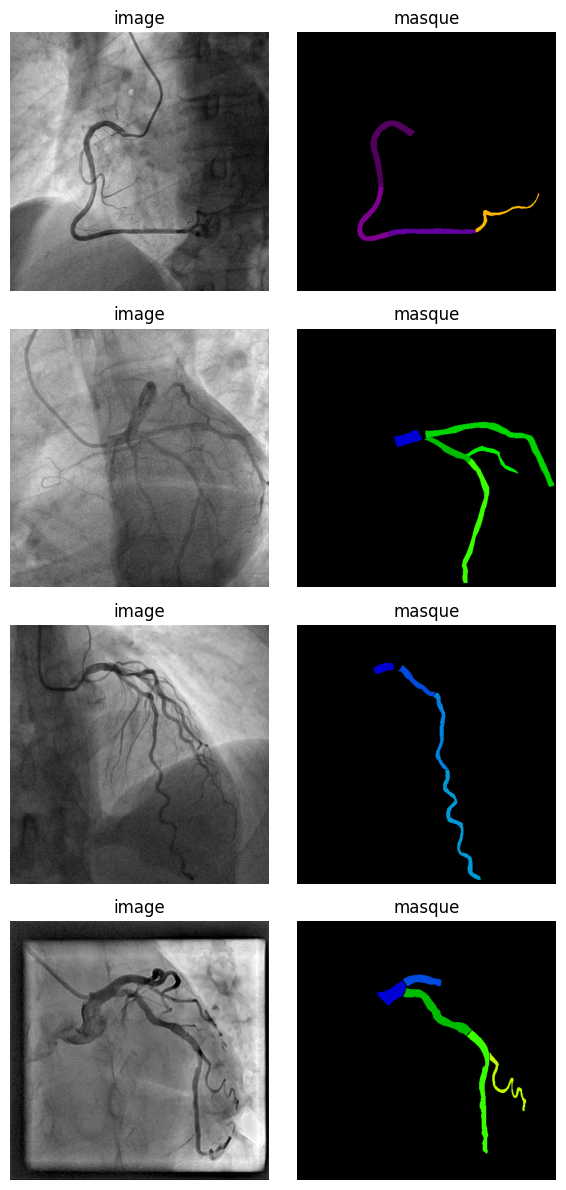

In [3]:
example_ds = ArcadeDataset(
    f"{DATA}/dataset_phase_1/segmentation_dataset/seg_train/images",
    f"{DATA}/dataset_phase_1/segmentation_dataset/seg_train/annotations/seg_train.json",
    img_size=IMG_SIZE,
    augment=False,
)
example_imgs = torch.stack([example_ds[i][0] for i in range(4)])
example_masks = torch.stack([example_ds[i][1] for i in range(4)])
show_rows(example_imgs, [("masque", example_masks)])

## Helpers : modèle, encodeur, entraînement, évaluation

In [4]:
EPOCHS = 20

def build_unet(in_channels):
    return smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=in_channels,
        classes=NUM_CLASSES,
        activation=None,
    ).to(device)

def load_medvae(source):
    from models.medvae import MVAE
    if source == "original":
        ddconfig = dict(
            double_z=True, z_channels=1, resolution=512, in_channels=1, out_ch=1,
            ch=128, ch_mult=[1, 2, 4], num_res_blocks=2, attn_resolutions=[], dropout=0.0,
        )
        mvae = MVAE(ddconfig=ddconfig, embed_dim=1, spatial_dims=2, apply_channel_ds=False, medvae_pretrained="medvae_4_1_2d")
        ae = mvae.model.to(device).eval()
        for p in ae.parameters():
            p.requires_grad = False
        return (lambda x: ae.encode(x * 2 - 1).mode()), 1

    cfg = load_config(f"{ROOT}/jepa_adaptation/configs/stage_2.yaml", f"{ROOT}/jepa_adaptation/configs/model.yaml")
    mc = cfg["model"]
    mvae = MVAE(
        ddconfig=mc["ddconfig"],
        embed_dim=int(mc["embed_dim"]),
        spatial_dims=2,
        apply_channel_ds=bool(mc["apply_channel_ds"]),
    )
    if source == "stage1":
        mvae.load_weights(f"{ROOT}/jepa_adaptation/outputs/stage1/best.pt")
    elif source == "stage2":
        ckpt = torch.load(f"{ROOT}/jepa_adaptation/outputs/stage2/best.pt", map_location="cpu")["model"]
        prefix = "context_encoder.autoencoder."
        state = {k[len(prefix):]: v for k, v in ckpt.items() if k.startswith(prefix)}
        mvae.model.load_state_dict(state, strict=False)
    else:
        raise ValueError(source)
    ae = mvae.model.to(device).eval()
    for p in ae.parameters():
        p.requires_grad = False
    return (lambda x: ae.encode(x * 2 - 1).mode()), int(mc["embed_dim"])

def train_model(model, forward_fn, lr):
    criterion = SegLoss(num_classes=NUM_CLASSES, dice_weight=0.5, ce_weight=0.5, cl_weight=0.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    for epoch in range(EPOCHS):
        model.train()
        running = 0.0
        for img, mask in train_loader:
            mask = mask.to(device)
            logits = forward_fn(img)
            loss, _ = criterion(logits, mask)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running += loss.item()
        print(f"epoch {epoch + 1}/{EPOCHS}  loss {running / len(train_loader):.4f}")

def evaluate(model, forward_fn):
    model.eval()
    metrics = SegMetrics(num_classes=NUM_CLASSES, device=device)
    with torch.no_grad():
        for img, mask in val_loader:
            metrics.update(forward_fn(img), mask.to(device))
    return metrics.compute()

def show_preds(forward_fn, title):
    img, mask = next(iter(val_loader))
    with torch.no_grad():
        pred = forward_fn(img).argmax(1).cpu()
    show_rows(img[:4], [("masque réel", mask[:4]), (title, pred[:4])])

def finetune_latent(source, lr=1e-3):
    encode, channels = load_medvae(source)
    model = build_unet(channels)
    def forward_fn(img):
        with torch.no_grad():
            z = encode(img.to(device))
        return F.interpolate(model(z), size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
    print(f"=== latent {source} (in_channels={channels}) ===")
    train_model(model, forward_fn, lr)
    res = evaluate(model, forward_fn)
    print(f"{source}: Dice {res['dice_mean']:.4f}  IoU {res['iou_mean']:.4f}")
    show_preds(forward_fn, f"pred {source}")
    return res, forward_fn

## 1. Fine-tune sur les images brutes

=== UNet image ===


epoch 1/20  loss 1.0697


epoch 2/20  loss 0.3937


epoch 3/20  loss 0.3098


epoch 4/20  loss 0.2774


...

epoch 17/20  loss 0.1685


epoch 18/20  loss 0.1671


epoch 19/20  loss 0.1650


epoch 20/20  loss 0.1620


image: Dice 0.3476  IoU 0.4320


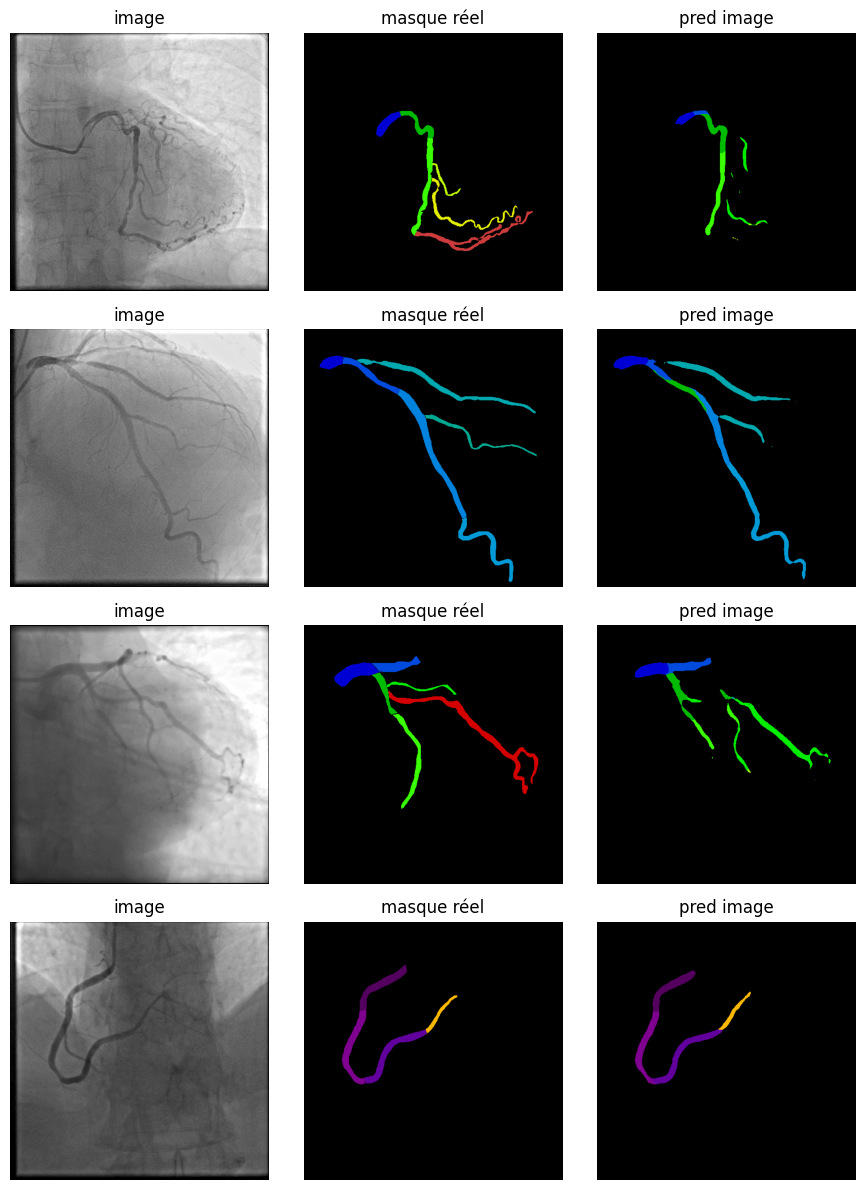

In [5]:
unet_image = build_unet(1)
def predict_image(img):
    return unet_image(img.to(device))

print("=== UNet image ===")
train_model(unet_image, predict_image, lr=1e-4)
res_image = evaluate(unet_image, predict_image)
print(f"image: Dice {res_image['dice_mean']:.4f}  IoU {res_image['iou_mean']:.4f}")
show_preds(predict_image, "pred image")

## 2. Fine-tune sur le latent MedVAE original

making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 1, 128, 128) = 16384 dimensions.
making attention of type 'vanilla' with 512 in_channels


[MVAE] loaded /home/infres/yrothlin-24/.cache/huggingface/hub/models--stanfordmimi--MedVAE/snapshots/8040c5ccb7a51eff6b4cef513c7f20bd1bda983d/model_weights/vae_4x_1c_2D.ckpt (0 missing, 8 unexpected)
[MVAE] unexpected keys:
    channel_ds.0.weight
    channel_ds.0.bias
    channel_ds.2.weight
    channel_ds.2.bias
    channel_ds.4.weight
    channel_ds.4.bias
    channel_proj.weight
    channel_proj.bias
=== latent original (in_channels=1) ===


epoch 1/20  loss 0.4621


epoch 2/20  loss 0.3017


epoch 3/20  loss 0.2933


...

epoch 17/20  loss 0.2052


epoch 18/20  loss 0.2046


epoch 19/20  loss 0.2018


epoch 20/20  loss 0.1968


original: Dice 0.3250  IoU 0.3682


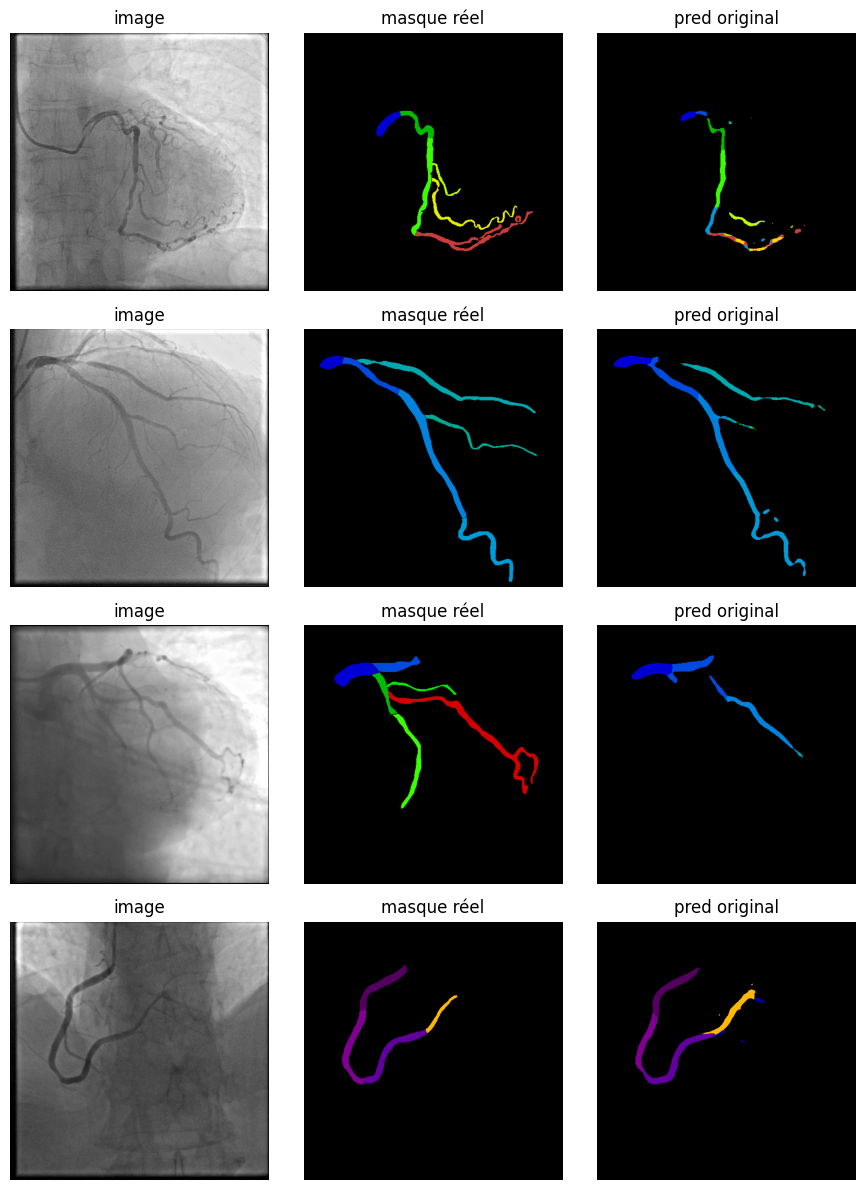

In [6]:
res_original, fwd_original = finetune_latent("original")

## 3. Fine-tune sur le latent MedVAE stage 1

making attention of type 'vanilla' with 256 in_channels
Working with z of shape (1, 1, 64, 64) = 4096 dimensions.
making attention of type 'vanilla' with 256 in_channels


[MVAE] loaded /home/infres/yrothlin-24/projet_IM06/jepa_adaptation/outputs/stage1/best.pt (0 missing, 0 unexpected)
=== latent stage1 (in_channels=1) ===


epoch 1/20  loss 0.4261


epoch 2/20  loss 0.3054


epoch 3/20  loss 0.2838


...

epoch 17/20  loss 0.2051


epoch 18/20  loss 0.2027


epoch 19/20  loss 0.2015


epoch 20/20  loss 0.1999


stage1: Dice 0.3155  IoU 0.3495


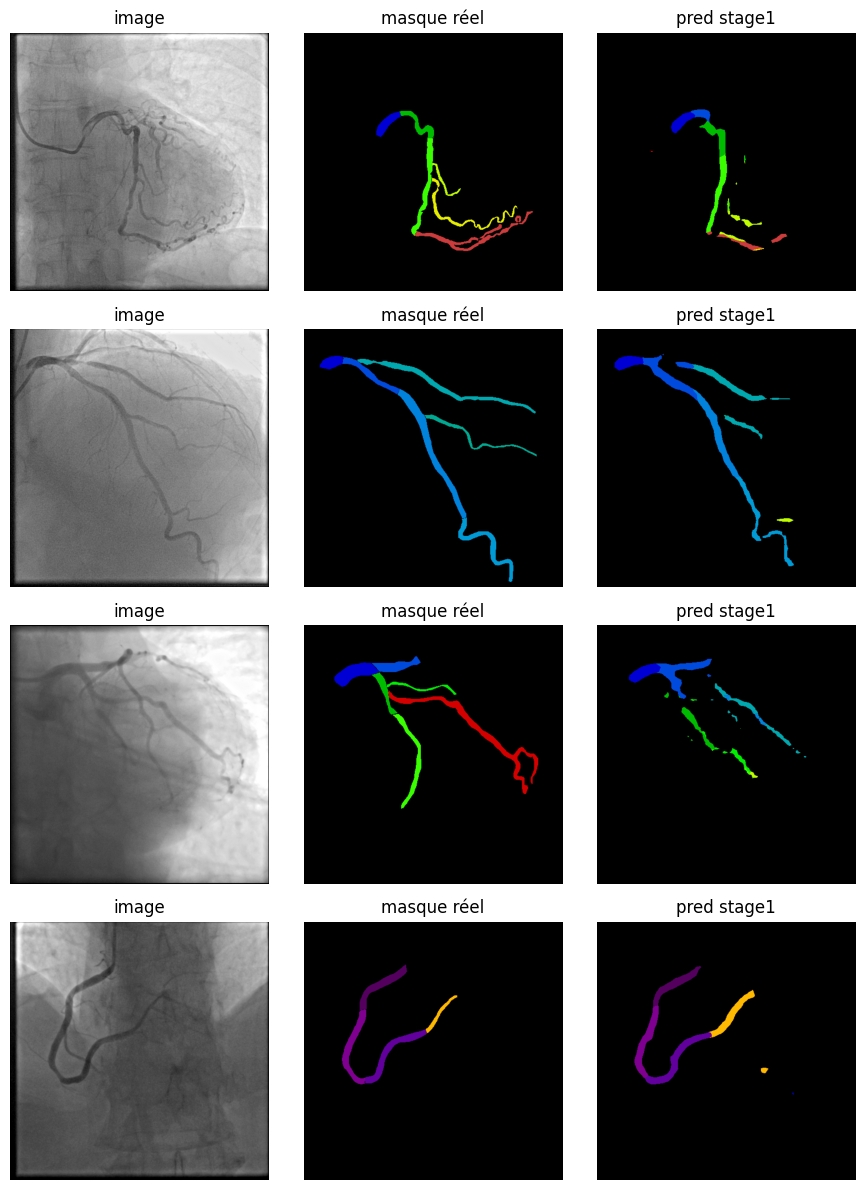

In [7]:
res_stage1, fwd_stage1 = finetune_latent("stage1")

## 4. Fine-tune sur le latent MedVAE stage 2

making attention of type 'vanilla' with 256 in_channels
Working with z of shape (1, 1, 64, 64) = 4096 dimensions.
making attention of type 'vanilla' with 256 in_channels


=== latent stage2 (in_channels=1) ===


epoch 1/20  loss 0.4649


epoch 2/20  loss 0.3150


epoch 3/20  loss 0.3052


...

epoch 17/20  loss 0.2348


epoch 18/20  loss 0.2290


epoch 19/20  loss 0.2288


epoch 20/20  loss 0.2288


stage2: Dice 0.2534  IoU 0.2664


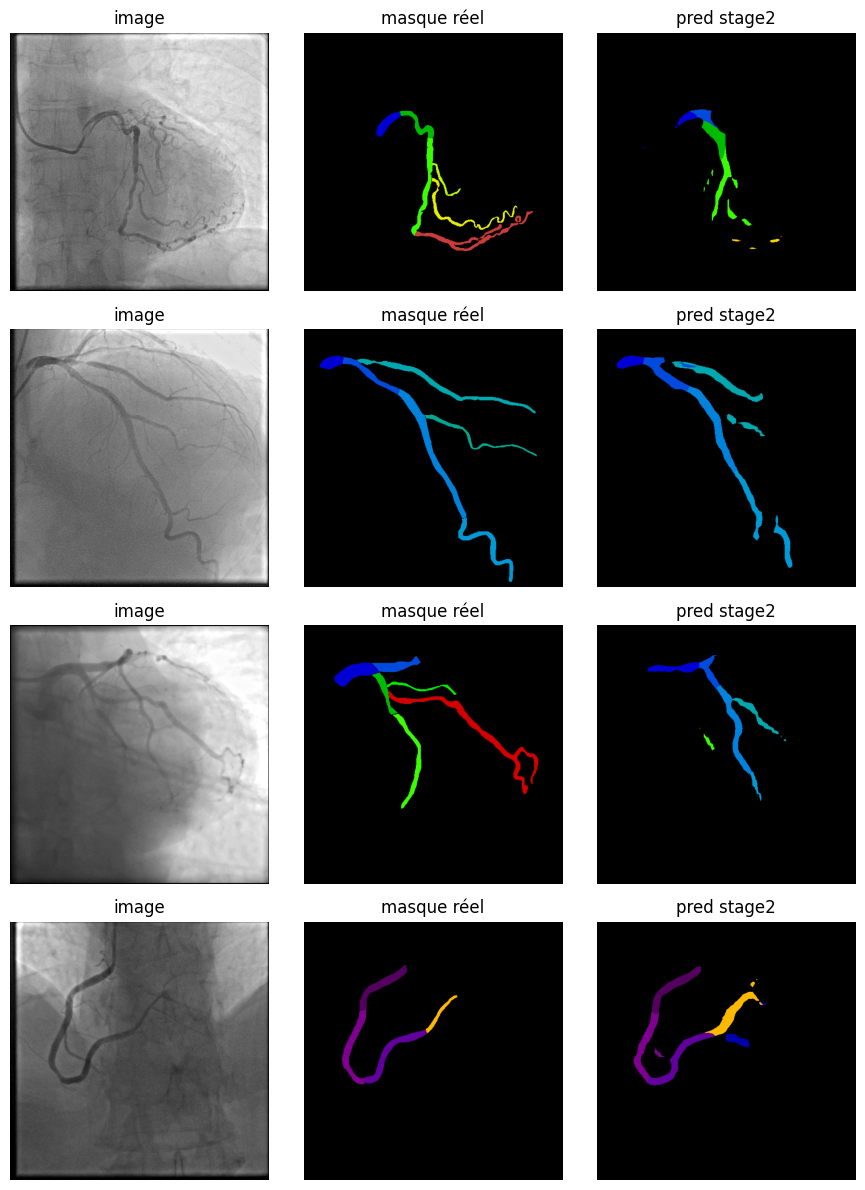

In [8]:
res_stage2, fwd_stage2 = finetune_latent("stage2")

## Comparaison finale

In [9]:
import pandas as pd

results = {
    "image":   res_image,
    "MedVAE":  res_original,
    "stage1":  res_stage1,
    "stage2":  res_stage2,
}
table = pd.DataFrame(
    {name: {"Dice": round(r["dice_mean"], 4), "IoU": round(r["iou_mean"], 4)} for name, r in results.items()}
).T
table.index.name = "modèle"
table

,Dice,IoU
modèle,,
image,0.3476,0.4320
MedVAE,0.3250,0.3682
stage1,0.3155,0.3495
stage2,0.2534,0.2664


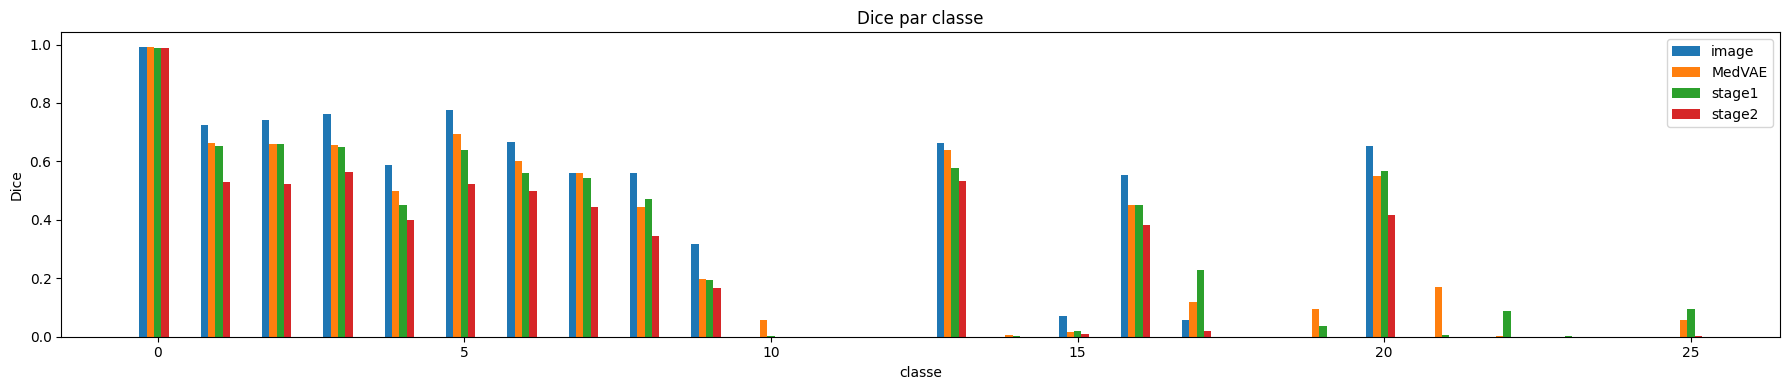

In [10]:
x = np.arange(NUM_CLASSES)
w = 0.12
plt.figure(figsize=(18, 4))
for i, (name, r) in enumerate(results.items()):
    plt.bar(x + (i - len(results) / 2) * w, r["dice_per_class"], width=w, label=name)
plt.xlabel("classe")
plt.ylabel("Dice")
plt.title("Dice par classe")
plt.legend()
plt.tight_layout()
plt.show()

## Prédictions comparées : image, masque réel et toutes les sorties

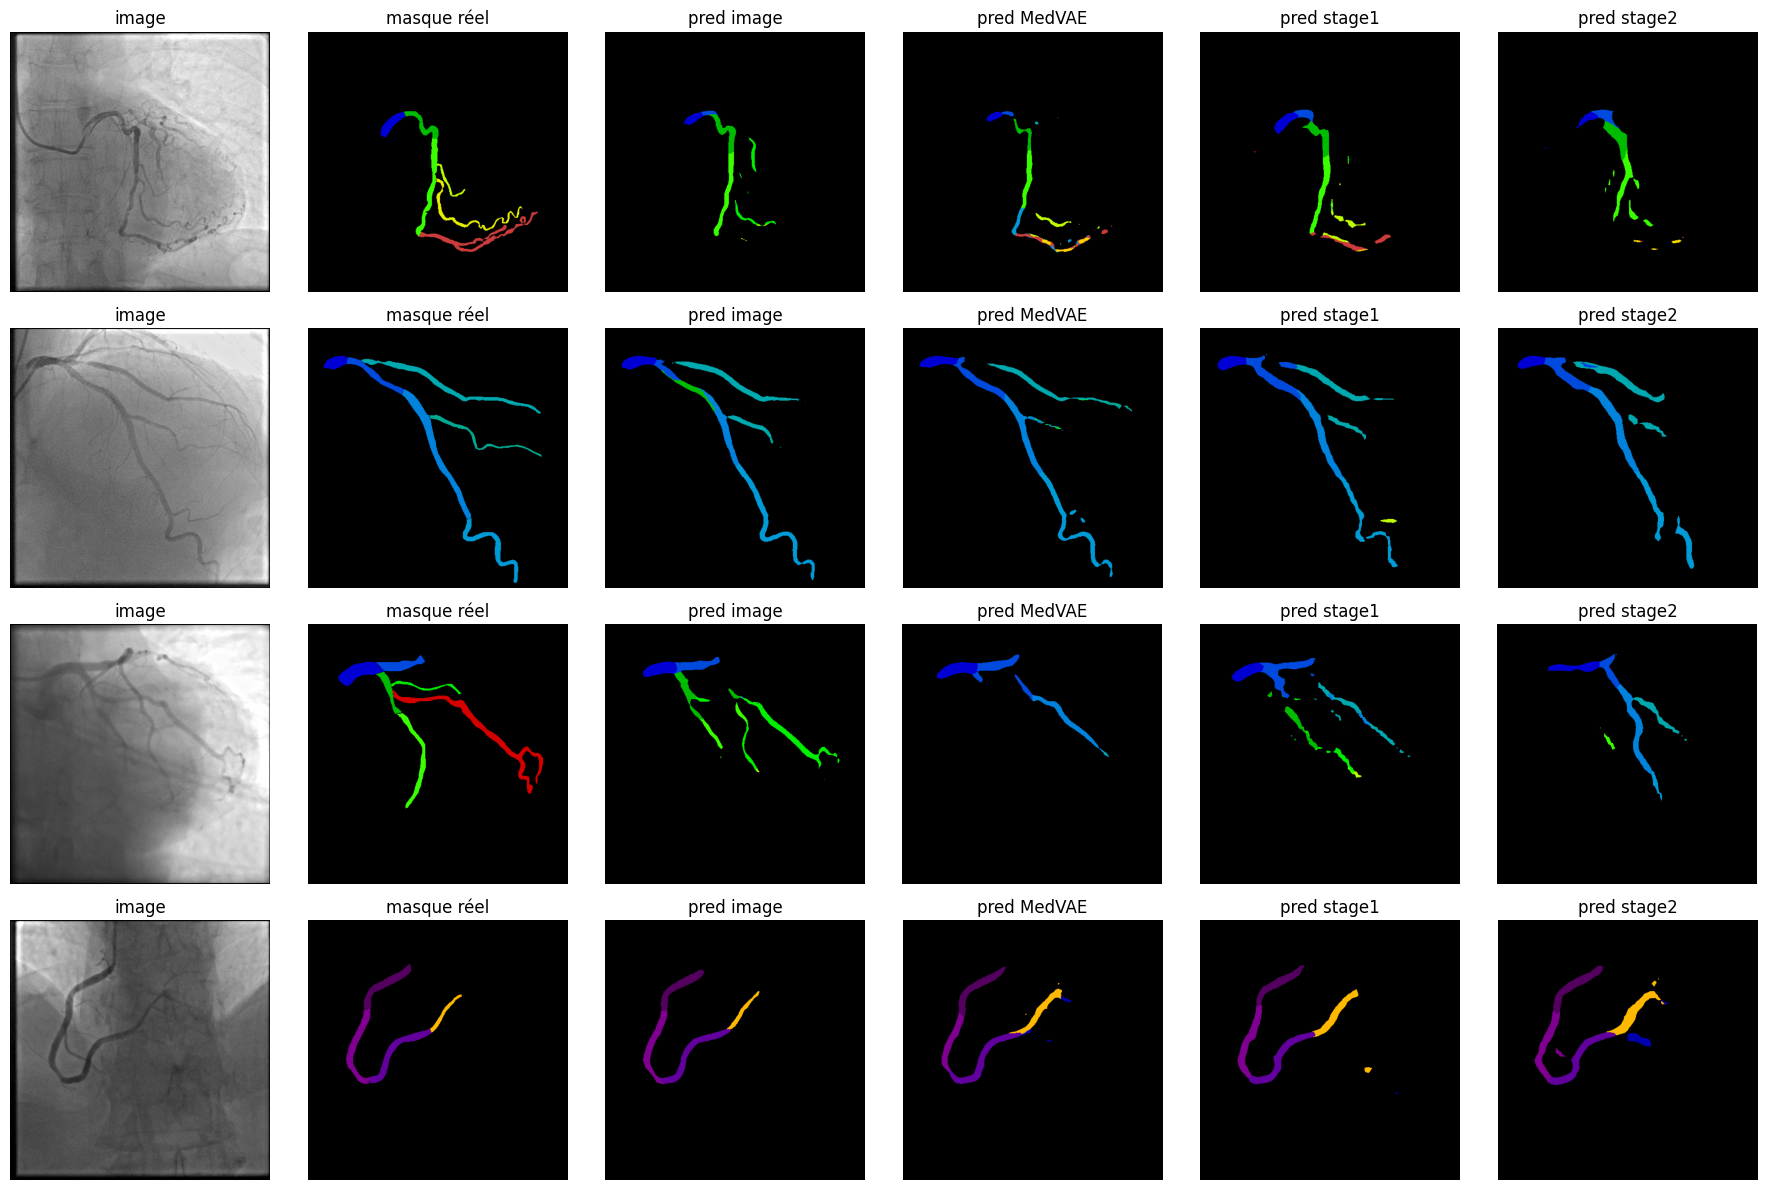

In [11]:
forwards = {
    "pred image":    predict_image,
    "pred MedVAE":   fwd_original,
    "pred stage1":   fwd_stage1,
    "pred stage2":   fwd_stage2,
}
img, mask = next(iter(val_loader))
panels = [("masque réel", mask[:4])]
for title, fn in forwards.items():
    with torch.no_grad():
        panels.append((title, fn(img).argmax(1).cpu()[:4]))
show_rows(img[:4], panels)